<a href="https://colab.research.google.com/github/Atikahdr/ArchTech_Titanic_DS/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Connect G-Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Load Data

In [ ]:
gender_data = pd.read_csv('/content/drive/MyDrive/Data Enthusiast Project/Arch-Data Science Intern/Titanic/gender_submission.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Data Enthusiast Project/Arch-Data Science Intern/Titanic/test.csv')
train_data = pd.read_csv('/content/drive/MyDrive/Data Enthusiast Project/Arch-Data Science Intern/Titanic/train.csv')

In [ ]:
print('Train Data:')
display(train_data)

print('\nTest Data:')
display(test_data)

print('\nGender Data:')
display(gender_data)

Train Data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C



Test Data:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S



Gender Data:


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
gender_data.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
test_data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [ ]:
datasets = {
    'train': train_data,
    'test': test_data,
    'gender': gender_data
}

In [ ]:
for name, data in datasets.items():
  print(f"\n Dataset: {name.upper()}")

  print('Shape :', data.shape)

  print('\nDuplicate Rows :', data.duplicated().sum())

  missing = data.isnull().sum()
  missing_percent = (missing / len(data)) * 100

  summary = pd.DataFrame({
      'Missing Value': missing,
      'Percentage': missing_percent
  })
  print(summary)



 Dataset: TRAIN
Shape : (891, 12)

Duplicate Rows : 0
             Missing Value  Percentage
PassengerId              0    0.000000
Survived                 0    0.000000
Pclass                   0    0.000000
Name                     0    0.000000
Sex                      0    0.000000
Age                    177   19.865320
SibSp                    0    0.000000
Parch                    0    0.000000
Ticket                   0    0.000000
Fare                     0    0.000000
Cabin                  687   77.104377
Embarked                 2    0.224467

 Dataset: TEST
Shape : (418, 11)

Duplicate Rows : 0
             Missing Value  Percentage
PassengerId              0    0.000000
Pclass                   0    0.000000
Name                     0    0.000000
Sex                      0    0.000000
Age                     86   20.574163
SibSp                    0    0.000000
Parch                    0    0.000000
Ticket                   0    0.000000
Fare                     1    0.2

The dataset shows good overall quality with no duplicate records and consistent structure between training and testing sets. However, several features contain missing values, notably Cabin with over 75% missing values, making it unsuitable for direct use. Age has around 20% missing values and requires imputation due to its potential predictive importance. Minor missing values in Embarked and Fare can be handled easily using simple imputation techniques. Overall, the dataset is clean and suitable for further preprocessing and modeling.

In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Cleaning Data

In [ ]:
#Drop PassengerId, Name, Ticket, & Cabin
train_data = train_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
test_data = test_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Fill Age & Fare by Median
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())

test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

# Fill Embarked by Mode
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

Data preprocessing was performed by removing irrelevant and low-quality features such as PassengerId, Name, Ticket, and Cabin. Missing values ​​in numeric features such as Age and Fare were handled using the median to maintain data distribution stability, while the categorical feature Embarked was imputed using the mode. This process resulted in a cleaner, simpler dataset, ready for use in the modeling phase.

In [ ]:
train_data.isnull().sum()


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
test_data.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      418 non-null    float64
 6   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 23.0+ KB


# 4. EDA

In [ ]:
sns.set_style('whitegrid')
train_data['Survived'].value_counts()

,count
Survived,
0,549
1,342


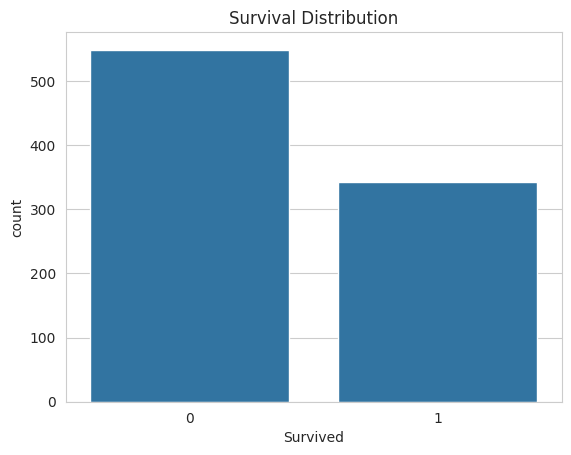

In [ ]:
sns.countplot(x='Survived', data=train_data)

plt.title('Survival Distribution')
plt.show()

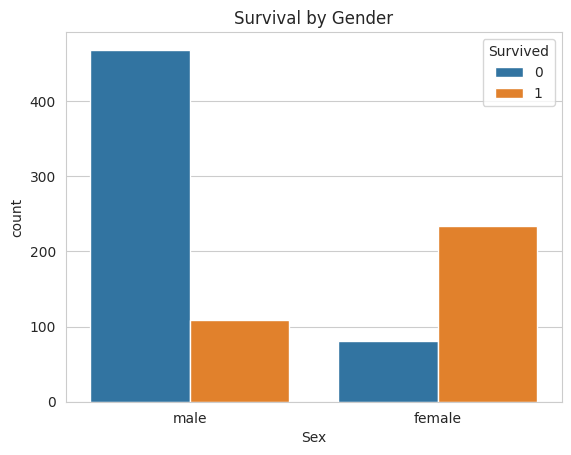

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=train_data)

plt.title('Survival by Gender')
plt.show()

## **Insight**

The analysis shows a significant difference in survival rates between genders. Female passengers had a much higher survival rate compared to males. This aligns with the historical evacuation policy of "women and children first", making gender one of the most influential features in predicting survival.

In [ ]:
train_data.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [ ]:
# Encode Sex
train_data['Sex'] = train_data['Sex'].map({
    'male':1,
    'female':0
})

# Encode Embarked
train_data['Embarked'] = train_data['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

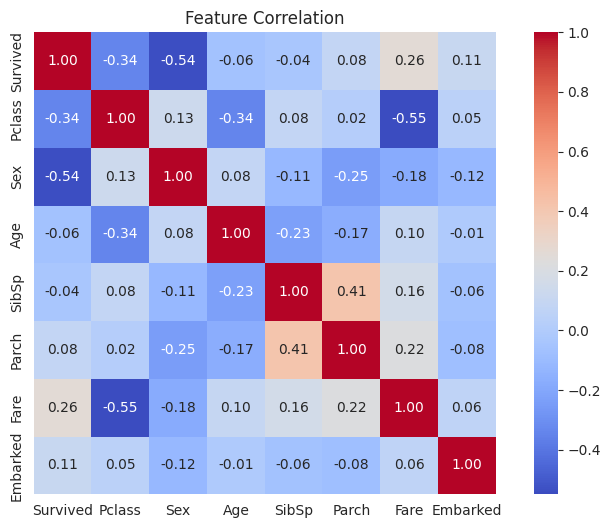

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(train_data.select_dtypes(include=['number']).corr(),
            annot=True,
            fmt='.2f',
            square=True,
            cmap="coolwarm")

plt.title('Feature Correlation')
plt.show()

Sex significantly influences survival.
- Negative values ​​arise due to encoding.

Pclass has a strong influence on survival.

Fare correlates with survival.

Age is not very strong but still useful.

SibSp and Parch are correlated with each other

# 5. Feature Engineering

In [ ]:
# Feature Engineering
train_data['Sex_Pclass'] = train_data['Sex'] * train_data['Pclass']
train_data['FareGroup'] = pd.cut(train_data['Fare'], bins=5)
train_data['AgeGroup'] = pd.cut(
                        train_data['Age'],
                        bins=[0,12,18,35,60,80],
                        labels=['Child', 'Teen', 'Young', 'Adult', 'Senior'])
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)
train_data['FarePerPerson'] = train_data['Fare'] / train_data['FamilySize']

In [ ]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_Pclass,FareGroup,AgeGroup,FamilySize,IsAlone,FarePerPerson
0,0,3,1,22.0,1,0,7.2500,0,3,"(-0.512, 102.466]",Young,2,0,3.62500
1,1,1,0,38.0,1,0,71.2833,1,0,"(-0.512, 102.466]",Adult,2,0,35.64165
2,1,3,0,26.0,0,0,7.9250,0,0,"(-0.512, 102.466]",Young,1,1,7.92500
3,1,1,0,35.0,1,0,53.1000,0,0,"(-0.512, 102.466]",Young,2,0,26.55000
4,0,3,1,35.0,0,0,8.0500,0,3,"(-0.512, 102.466]",Young,1,1,8.05000


In [ ]:
#Encode FareGroup & AgeGroup
train_data = pd.get_dummies(train_data, columns=['FareGroup', 'AgeGroup'], drop_first=True)

In [ ]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_Pclass,FamilySize,IsAlone,FarePerPerson,"FareGroup_(102.466, 204.932]","FareGroup_(204.932, 307.398]","FareGroup_(307.398, 409.863]","FareGroup_(409.863, 512.329]",AgeGroup_Teen,AgeGroup_Young,AgeGroup_Adult,AgeGroup_Senior
0,0,3,1,22.0,1,0,7.2500,0,3,2,0,3.62500,False,False,False,False,False,True,False,False
1,1,1,0,38.0,1,0,71.2833,1,0,2,0,35.64165,False,False,False,False,False,False,True,False
2,1,3,0,26.0,0,0,7.9250,0,0,1,1,7.92500,False,False,False,False,False,True,False,False
3,1,1,0,35.0,1,0,53.1000,0,0,2,0,26.55000,False,False,False,False,False,True,False,False
4,0,3,1,35.0,0,0,8.0500,0,3,1,1,8.05000,False,False,False,False,False,True,False,False


# Feature and Target

In [ ]:
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

print('Shape Feature:', X.shape)
print('Shape Target:', y.shape)

Shape Feature: (891, 19)
Shape Target: (891,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (712, 19)
X_test: (179, 19)
y_train: (712,)
y_test: (179,)


In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


# Scaling Data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Modelling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict


In [ ]:
models = []

models.append(('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')))
models.append(('Random Forest', RandomForestClassifier(random_state=42, class_weight='balanced')))
models.append(('Decision Tree', DecisionTreeClassifier(random_state=42, class_weight='balanced')))
models.append(('SVM', SVC(probability=True, random_state=42, class_weight='balanced')))
models.append(('KNN', KNeighborsClassifier()))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models:

    # Accuracy Cross Validation
    cv_acc = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring='accuracy',
        error_score='raise'
    )

    # Predict Probability for ROC AUC
    y_proba = cross_val_predict(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        method="predict_proba"
    )[:,1]

    # ROC AUC Score
    roc_auc = roc_auc_score(y_train, y_proba)

    # Save result
    results.append([
        name,
        round(roc_auc * 100, 2),
        round(cv_acc.mean() * 100, 2),
        round(cv_acc.std() * 100, 2)
    ])

# Model Comparison
col = ['Algorithm', 'ROC AUC Mean', 'Accuracy Mean', 'Accuracy STD']
model_result = pd.DataFrame(results, columns=col)
model_result = model_result.sort_values(by='ROC AUC Mean', ascending=False)

print('\nModel Comparison Results')
print(model_result)

best_model_name = model_result.iloc[0]['Algorithm']
best_model = dict(models)[best_model_name]
best_model.fit(X_train_scaled, y_train)

print(f"\nBest Model: {best_model_name}")


Model Comparison Results
             Algorithm  ROC AUC Mean  Accuracy Mean  Accuracy STD
1        Random Forest         86.55          81.04          1.38
0  Logistic Regression         85.38          79.92          2.96
3                  SVM         84.57          80.06          2.69
4                  KNN         82.70          78.52          2.49
2        Decision Tree         76.15          76.83          2.42

Best Model: Random Forest


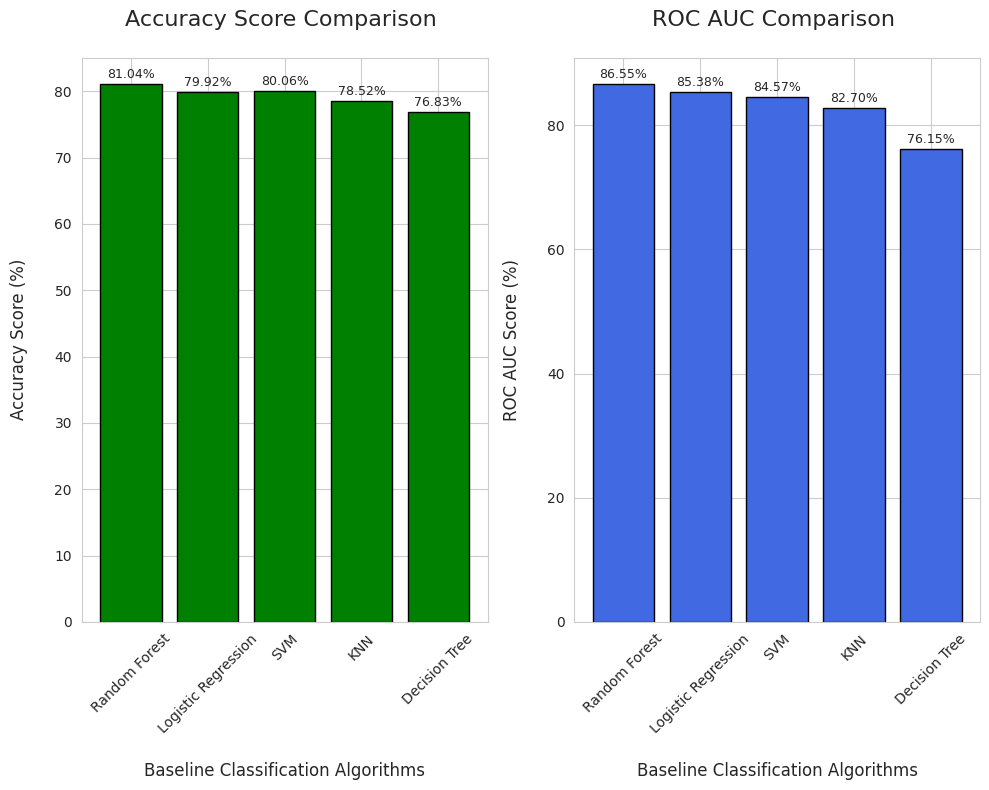

In [ ]:
# Step 15.2.  Visualize Classification Algorithms Accuracy Comparisons:
fig, axes = plt.subplots(1, 2, figsize=(10,8))

# Subplot 1 - Accuracy Comparison
bars1 = axes[0].bar(model_result['Algorithm'], model_result['Accuracy Mean'],
                    color='green', edgecolor='black')
axes[0].set_ylabel('Accuracy Score (%)\n', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[0].set_xlabel('\nBaseline Classification Algorithms', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[0].set_title('Accuracy Score Comparison \n', horizontalalignment="center",
                  fontstyle="normal", fontsize=16, fontfamily="sans-serif")
axes[0].tick_params(axis='x', rotation=45)

# persentase bar Accuracy
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# Subplot 2 - ROC AUC Comparison
bars2 = axes[1].bar(model_result['Algorithm'], model_result['ROC AUC Mean'],
                    color='royalblue', edgecolor='black')
axes[1].set_ylabel('ROC AUC Score (%)\n', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[1].set_xlabel('\nBaseline Classification Algorithms', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[1].set_title('ROC AUC Comparison \n', horizontalalignment="center",
                  fontstyle="normal", fontsize=16, fontfamily="sans-serif")
axes[1].tick_params(axis='x', rotation=45)

# persentase bar ROC AUC
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print('Best Parameters:', grid.best_params_)
print('Best ROC AUC:', grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best ROC AUC: 0.8726521616372714


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Train Model
rf_model = grid.best_estimator_

rf_model.fit(X_train_scaled, y_train)

# Train Set Evaluation
y_train_pred = rf_model.predict(X_train_scaled)
y_train_prob = rf_model.predict_proba(X_train_scaled)[:,1]

train_acc = accuracy_score(y_train, y_train_pred)
train_roc = roc_auc_score(y_train, y_train_prob)

print('Overfitting Check - Random Forest')

print('\n Train Set')
print('Accuracy:', round(train_acc*100,2), '%')
print('ROC AUC:', round(train_roc*100,2), '%')

# Test Set Evaluation
y_test_pred = rf_model.predict(X_test_scaled)
y_test_prob = rf_model.predict_proba(X_test_scaled)[:,1]

test_acc = accuracy_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_prob)

print('\n Test Set')
print('Accuracy:', round(test_acc*100,2), '%')
print('ROC AUC:', round(test_roc*100,2),'%')

# GAP Overfitting
print('\n GAP (Train - Test)')

print('Accuracy GAP:', round((train_acc - test_acc)*100,2), '%')
print('ROC AUC GAP:', round((train_roc - test_roc)*100,2), '%')

Overfitting Check - Random Forest

 Train Set
Accuracy: 85.81 %
ROC AUC: 91.58 %

 Test Set
Accuracy: 79.33 %
ROC AUC: 83.38 %

 GAP (Train - Test)
Accuracy GAP: 6.48 %
ROC AUC GAP: 8.2 %


The Random Forest model shows a small performance gap between the training and testing sets. The training accuracy is 85.81% while the testing accuracy is 79.33%, resulting in an accuracy gap of 6.48%. Similarly, the ROC AUC gap is 8.2%. This indicates a mild level of overfitting, which is common for tree-based ensemble models, but the gap remains within an acceptable range. Overall, the model demonstrates good generalization performance.

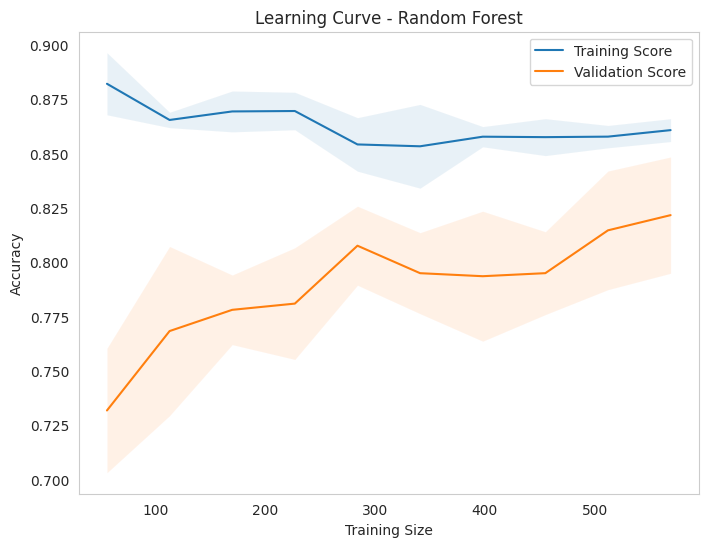

In [ ]:
from sklearn.model_selection import learning_curve

rf_model = grid.best_estimator_

# Calculate Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, val_mean, label='Validation Score')

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)

plt.title('Learning Curve - Random Forest')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

The learning curve shows that the training accuracy is consistently higher than the validation accuracy, indicating a mild level of overfitting. However, as the training size increases, the gap between training and validation performance decreases and stabilizes. This suggests that the model generalizes reasonably well and additional data could further improve performance

# Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

                         Feature  Importance
7                     Sex_Pclass    0.268336
1                            Sex    0.234189
5                           Fare    0.114483
10                 FarePerPerson    0.100434
0                         Pclass    0.082111
2                            Age    0.070631
8                     FamilySize    0.042918
6                       Embarked    0.017920
4                          Parch    0.015534
3                          SibSp    0.014324
9                        IsAlone    0.011828
17                AgeGroup_Adult    0.007937
11  FareGroup_(102.466, 204.932]    0.007213
16                AgeGroup_Young    0.004988
15                 AgeGroup_Teen    0.003337
18               AgeGroup_Senior    0.002515
12  FareGroup_(204.932, 307.398]    0.001237
14  FareGroup_(409.863, 512.329]    0.000065
13  FareGroup_(307.398, 409.863]    0.000000


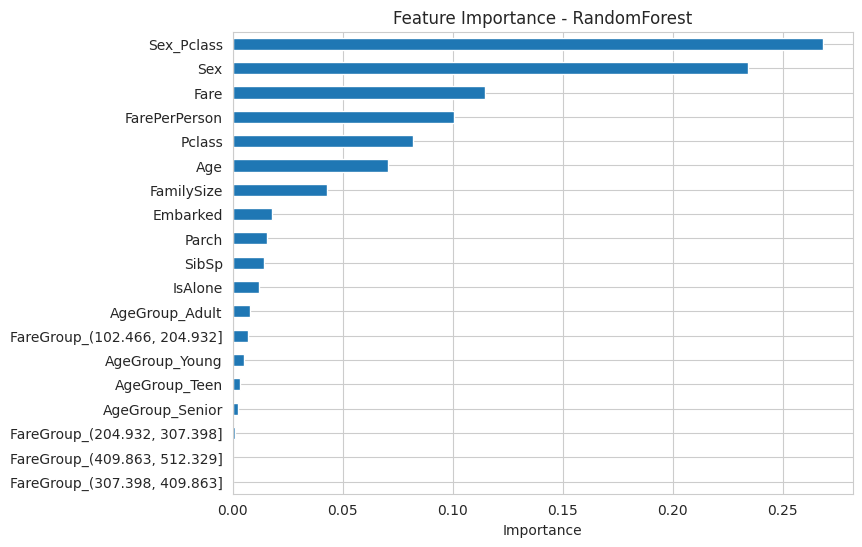

In [ ]:
# Train model
rf = grid.best_estimator_
rf.fit(X_train, y_train)

importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance - RandomForest")
plt.xlabel("Importance")
plt.show()


The most important feature is the interaction between gender and passenger class (Sex_Pclass), indicating that survival was strongly influenced by both social status and gender. Gender alone remains a dominant predictor, confirming that females had a significantly higher chance of survival. Additionally, fare-related features suggest that wealthier passengers were more likely to survive. In contrast, engineered categorical features such as FareGroup and AgeGroup contributed minimally, indicating that the original continuous variables captured the information more effectively.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Random Forest
print('\nRandom Forest')

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth = 5,
    min_samples_leaf = 2,
    min_samples_split =  10,
    n_estimators = 100
)

rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:,1]

print('Accuracy:', round(accuracy_score(y_test, y_pred)*100,2))
print('ROC AUC:', round(roc_auc_score(y_test, y_prob)*100,2))

print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

#  Logistic Regression
print('\nLogistic Regression')
log_reg = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

print('Accuracy:', round(accuracy_score(y_test, y_pred)*100,2))
print('ROC AUC:', round(roc_auc_score(y_test, y_prob)*100,2))

print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# SVM
print('\nSVM')

svm_model = SVC(probability=True, random_state=42, class_weight='balanced')

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)[:,1]

print('Accuracy:', round(accuracy_score(y_test, y_pred)*100,2))
print('ROC AUC:', round(roc_auc_score(y_test, y_prob)*100,2))

print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# KNN
print('\nKNN')

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)
y_prob = knn_model.predict_proba(X_test_scaled)[:,1]

print('Accuracy:',  round(accuracy_score(y_test, y_pred)*100,2))
print('ROC AUC:', round(roc_auc_score(y_test, y_prob)*100,2))

print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# Decision Tree
print('\nDecision Tree')

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train_scaled, y_train)

y_pred = dt_model.predict(X_test_scaled)
y_prob = dt_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100,2))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob)*100,2))

print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))


Random Forest
Accuracy: 79.33
ROC AUC: 83.38

Confusion Matrix:
 [[89 21]
 [16 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83       110
           1       0.72      0.77      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.80      0.79      0.79       179


Logistic Regression
Accuracy: 79.33
ROC AUC: 86.09

Confusion Matrix:
 [[92 18]
 [19 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83       110
           1       0.74      0.72      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


SVM
Accuracy: 81.56
ROC AUC: 83.98

Confusion Matrix:
 [[94 16]
 [17 52]]

Classification Report:
               precis

Among the evaluated models, Logistic Regression achieved the highest ROC AUC score (86.09%), indicating the best ability to distinguish between survivors and non-survivors. Although SVM produced the highest accuracy (81.56%), Logistic Regression demonstrated better overall classification performance based on probability ranking.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1','l2'],
    'solver': ['liblinear','saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 2000]
}

log_reg = LogisticRegression(random_state=42)

grid = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC AUC:", grid.best_score_)

Best Parameters: {'C': 1, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC AUC: 0.8567561719599338


In [ ]:
best_log_model = grid.best_estimator_

y_pred = best_log_model.predict(X_test_scaled)
y_prob = best_log_model.predict_proba(X_test_scaled)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_prob))

Accuracy: 0.8156424581005587
ROC AUC: 0.8631093544137023


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Train Model
best_log_model = grid.best_estimator_

best_log_model.fit(X_train_scaled, y_train)

# Train Set Evaluation
y_train_pred = best_log_model.predict(X_train_scaled)
y_train_prob = best_log_model.predict_proba(X_train_scaled)[:,1]

train_acc = accuracy_score(y_train, y_train_pred)
train_roc = roc_auc_score(y_train, y_train_prob)

print('Overfitting Check - Logistic Regression')

print('\n Train Set')
print('Accuracy:', round(train_acc*100,2), '%')
print('ROC AUC:', round(train_roc*100,2), '%')

# Test Set Evaluation
y_test_pred = best_log_model.predict(X_test_scaled)
y_test_prob = best_log_model.predict_proba(X_test_scaled)[:,1]

test_acc = accuracy_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_prob)

print('\n Test Set')
print('Accuracy:', round(test_acc*100,2), '%')
print('ROC AUC:', round(test_roc*100,2),'%')

# GAP Overfitting
print('\n GAP (Train - Test)')

print('Accuracy GAP:', round((train_acc - test_acc)*100,2), '%')
print('ROC AUC GAP:', round((train_roc - test_roc)*100,2), '%')

Overfitting Check - Logistic Regression

 Train Set
Accuracy: 83.01 %
ROC AUC: 87.18 %

 Test Set
Accuracy: 81.56 %
ROC AUC: 86.31 %

 GAP (Train - Test)
Accuracy GAP: 1.44 %
ROC AUC GAP: 0.87 %


# Best Model - Logistic Regression

In [ ]:
#  Logistic Regression
print('\nLogistic Regression')
log_reg = grid.best_estimator_
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

print('Accuracy:', round(accuracy_score(y_test, y_pred)*100,2))
print('ROC AUC:', round(roc_auc_score(y_test, y_prob)*100,2))

print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))


Logistic Regression
Accuracy: 81.56
ROC AUC: 86.31

Confusion Matrix:
 [[101   9]
 [ 24  45]]


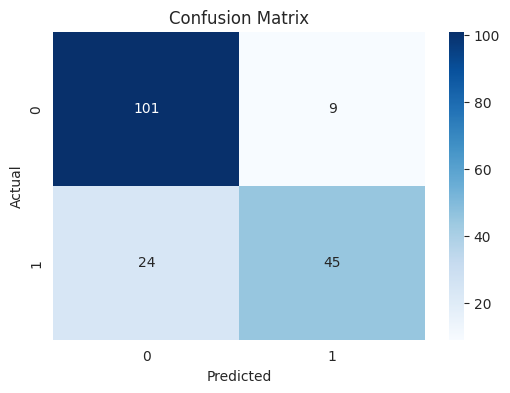

In [ ]:
# Confusion Matrix
best_log_model = grid.best_estimator_

y_pred = best_log_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

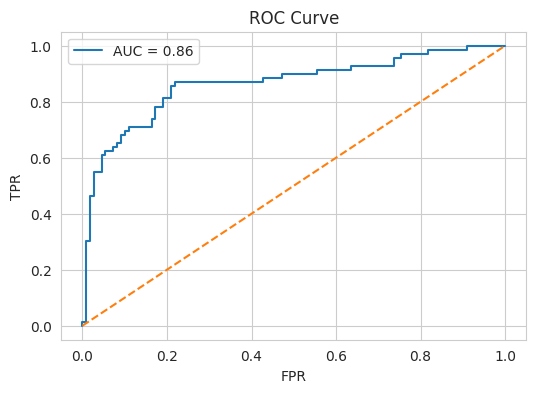

In [ ]:
from sklearn.metrics import roc_curve

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc_score(y_test, y_prob))
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()

## **Bussiness Insight**

The analysis reveals that survival was heavily influenced by structured prioritization and social hierarchy. Gender was the most significant factor, with females having a much higher survival rate due to evacuation policies. Additionally, passengers in higher classes and with higher fares had better access to safety resources, highlighting inequality in survival opportunities. The interaction between gender and class further emphasizes that both identity and position played a critical role in determining outcomes.